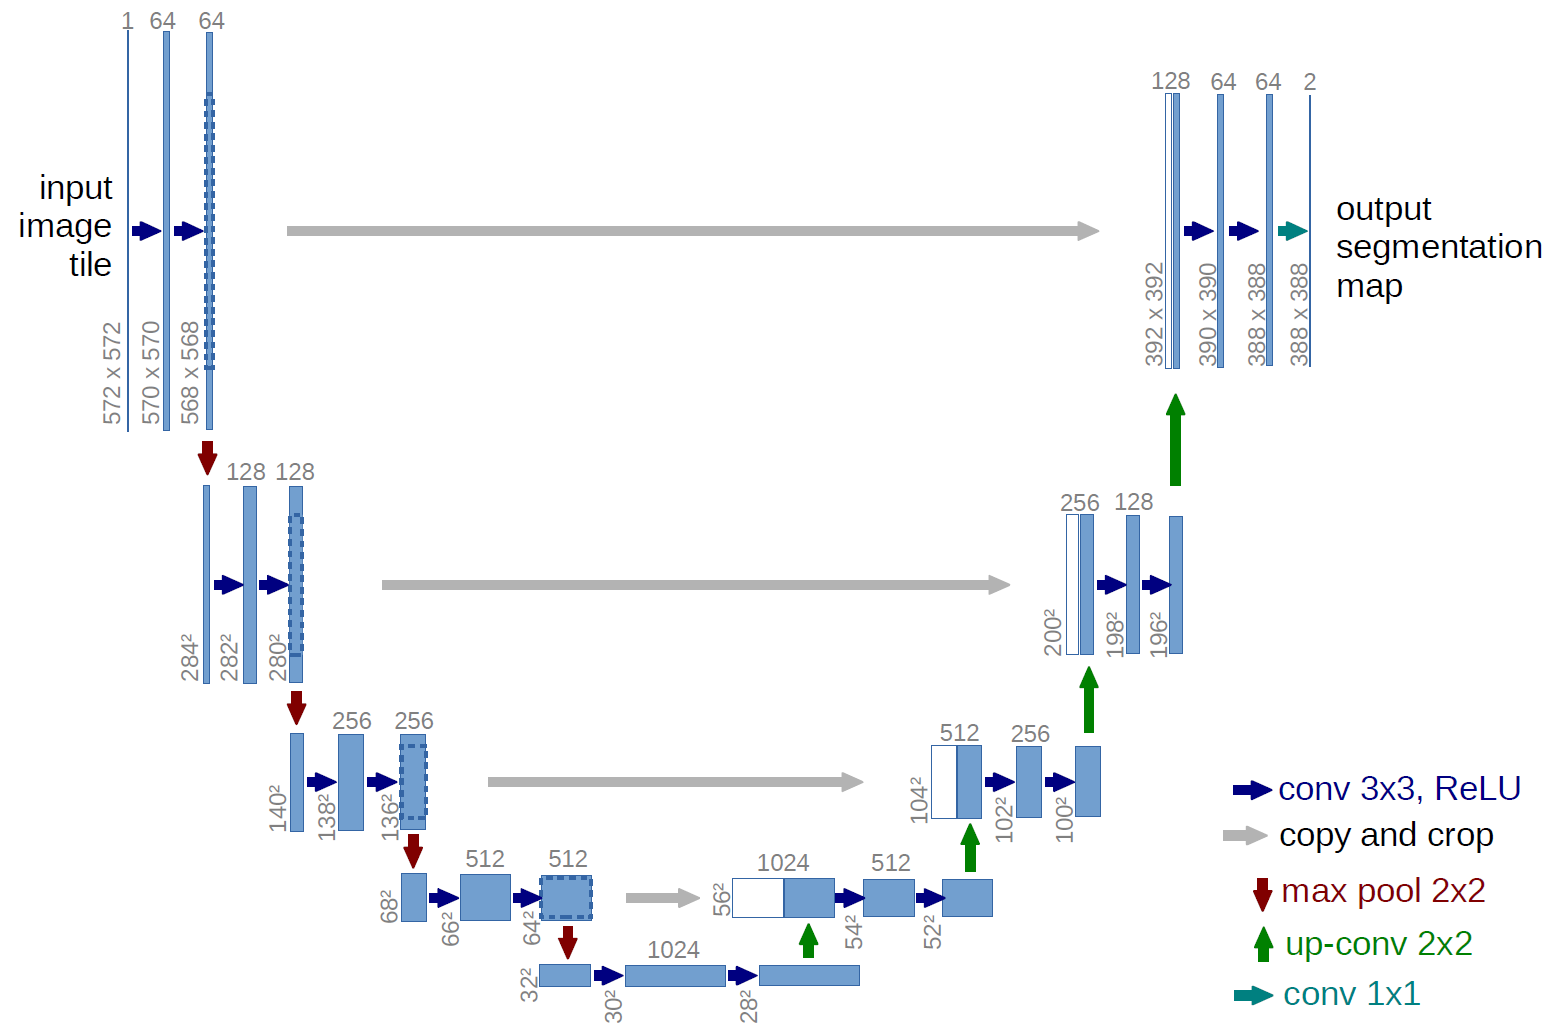

Bus du input channeliai - kur juoda, kur balta 256 x 256 x 2

In [1]:
import torch
import torch.nn as nn

use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")
print("CUDA:", use_cuda, "| device:", device)

CUDA: True | device: cuda:0


In [2]:
import sys, torch
print(sys.executable)
print(sys.version)
print(torch.__version__, torch.version.cuda)
print(torch.cuda.is_available(), torch.cuda.device_count())

C:\Users\ELVIS HOME\PycharmProjects\deep-learning\.venv\Scripts\python.exe
3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]
2.11.0+cu128 12.8
True 1


In [ ]:
# import os
# from datasets import load_dataset
# ds = load_dataset("ioclab/light", split="train[:60000]")  # Dataset
# split = ds.train_test_split(test_size=0.2, seed=200)      # split directly
# train_ds = split["train"]
# validate_ds = split["test"]
#
# print(train_ds)
# print(validate_ds)


Modelis (pagal schema)

In [3]:
class ColoringModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.steps1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding='same'),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding='same'),
            nn.BatchNorm2d(16),
            nn.ReLU()
        )

        self.steps2 = nn.Sequential(
            nn.MaxPool2d(2, 2), # 256x256 -> 128x128
            nn.Conv2d(16, 32, kernel_size=3, padding='same'),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding='same'),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.steps3 = nn.Sequential(
            nn.MaxPool2d(2, 2), # 128x128 -> 64x64
            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.steps4 = nn.Sequential(
            nn.MaxPool2d(2, 2), # 64x64 -> 32x32
            nn.Conv2d(64, 128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.steps5 = nn.Sequential(
            nn.MaxPool2d(2, 2), # 32x32 -> 16x16
            nn.Conv2d(128, 256, kernel_size=3, padding='same'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Upsample(scale_factor=2), # 16x16 -> 32x32
        )

        self.steps6 = nn.Sequential(
            # 128 + 128 (step 4) = 256 kanalai
            nn.Conv2d(256, 128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Upsample(scale_factor=2), # 32x32 -> 64x64
        )

        self.steps7 = nn.Sequential(
            # 64 + (step 3) 64 = 128 kanalai
            nn.Conv2d(128, 64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding='same'),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Upsample(scale_factor=2), # 64x64 -> 128x128
        )

        self.steps8 = nn.Sequential(
            # 32 + 32 (step 2) = 64 kanalai
            nn.Conv2d(64, 32, kernel_size=3, padding='same'),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 16, kernel_size=3, padding='same'),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Upsample(scale_factor=2), # 128x128 -> 256x256
        )

        self.steps9 = nn.Sequential(
            # 16 + 16 (step 1) kanalai = 32 kanalai
            nn.Conv2d(32, 16, kernel_size=3, padding='same'),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding='same'),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 3, kernel_size=3, padding='same'),
            nn.Sigmoid()
        )

    def forward(self, x):
        block1 = self.steps1(x)
        block2 = self.steps2(block1)
        block3 = self.steps3(block2)
        block4 = self.steps4(block3)

        block5 = self.steps5(block4)

        # concat
        block6 = self.steps6(torch.cat([block5, block4], dim=1))
        block7 = self.steps7(torch.cat([block6, block3], dim=1))
        block8 = self.steps8(torch.cat([block7, block2], dim=1))
        block9 = self.steps9(torch.cat([block8, block1], dim=1))

        return block9

In [4]:
import numpy as np
def evaluate(model, loader):
    model.eval()
    loss_func = torch.nn.SmoothL1Loss() # ta pati loss funkcija kaip ir per traininga
    loss_acum = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            pred = model(images)
            loss = loss_func(pred, labels)
            loss_acum.append(loss.item())

    return np.mean(loss_acum)


In [5]:
from datetime import datetime
import torch.nn.functional as F

def colorization_loss(pred, target):
    l1 = F.smooth_l1_loss(pred, target)
    pred_sat = torch.abs(pred)
    target_sat = torch.abs(target)
    sat_loss = F.smooth_l1_loss(pred_sat, target_sat)
    return l1 + 0.5 * sat_loss

def train(model, loader, epoch_count = 10, lr = 1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # zinant kaip blogai modelis pasirode, patikrina, kaip pakeisti svoriu vertes, kad modelis klystu maziau
    # learning rate standartine yra 1e-3 (0.001), is esmes zingsnio dydis keiciant svorius

    model.train()
    start_time = datetime.now()

    for epoch in range(epoch_count):
        loss_acum = []
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device) # sumappinami images ir labels
            optimizer.zero_grad() # praeito zingsnio skaiciavimai panaikinami
            pred = model(images) # predictionai
            loss = colorization_loss(pred, labels) # losses paskaiciavimai
            loss.backward() # paskaiciuojama, kaip kiekvienas svoris prisidejo prie klaidu skaiciaus
            optimizer.step() # optimizuojami svoriai, kad butu sumazintos klaidos
            loss_acum.append(loss.item())
        current_time = datetime.now()
        elapsed = seconds_to_time((current_time - start_time).total_seconds())
        print(f'Epoch: {epoch}, Time: {elapsed}, Loss: {np.mean(loss_acum)}')



def seconds_to_time(seconds):
    s = int(seconds) % 60
    m = int(seconds) // 60
    if m < 1:
        return f'{s}s'
    h = m // 60
    m = m % 60
    if h < 1:
        return f'{m}m{s}s'
    return f'{h}h{m}m{s}s'

In [6]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image

import torch
from torch.utils.data import DataLoader, random_split
from dataset import LocalColorizationDataset

IMAGE_FOLDER_PATH = "./val2014"
full_dataset = LocalColorizationDataset(IMAGE_FOLDER_PATH, limit=50000)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, validate_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(200)
)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(validate_dataset)}")

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

validate_loader = DataLoader(
    validate_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)


Training dataset size: 32403
Validation dataset size: 8101


In [7]:

model = ColoringModel().to(device)


print("Starting training...")
train(model, train_loader, epoch_count=15, lr=1e-3)


print("Evaluating...")
val_loss = evaluate(model, validate_loader)
print(f"Validation Loss: {val_loss}")


Starting training...
Epoch: 0, Time: 15m50s, Loss: 0.007256178009345775
Epoch: 1, Time: 31m41s, Loss: 0.005339595168374303
Epoch: 2, Time: 47m29s, Loss: 0.005152936856167053
Epoch: 3, Time: 1h3m16s, Loss: 0.004979264636443356
Epoch: 4, Time: 1h19m3s, Loss: 0.004880591236076897
Epoch: 5, Time: 1h34m41s, Loss: 0.004870340063999312
Epoch: 6, Time: 1h50m19s, Loss: 0.004765112802760279
Epoch: 7, Time: 2h5m56s, Loss: 0.004726221305538174
Epoch: 8, Time: 2h21m36s, Loss: 0.0046757003255775125
Epoch: 9, Time: 2h37m13s, Loss: 0.004632079347740771
Epoch: 10, Time: 2h52m50s, Loss: 0.004580765584938404
Epoch: 11, Time: 3h8m27s, Loss: 0.004538774009112004
Epoch: 12, Time: 3h24m4s, Loss: 0.004556220969896559
Epoch: 13, Time: 3h39m41s, Loss: 0.00450045449428231
Epoch: 14, Time: 3h55m18s, Loss: 0.00445998931765615
Evaluating...
Validation Loss: 0.003360823593538953


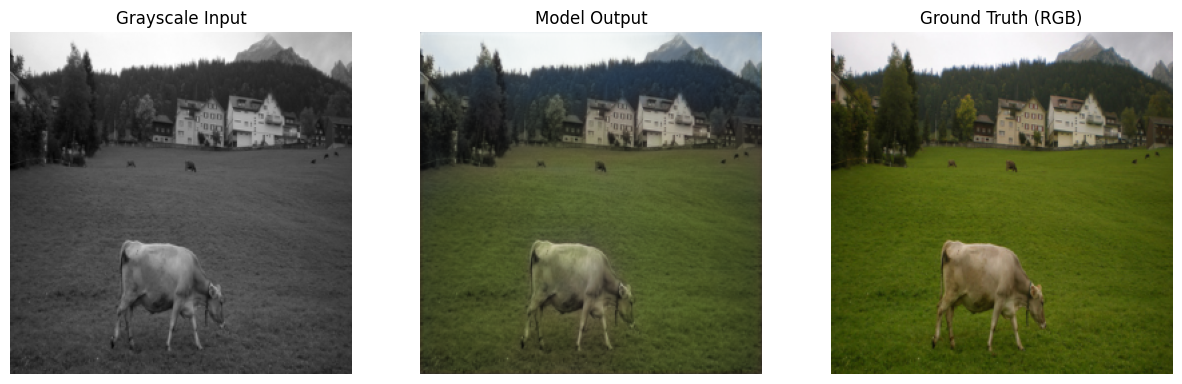

In [37]:
import matplotlib.pyplot as plt

def visualize_result(model, dataset, index=0):
    model.eval()
    inp, target = dataset[index]

    with torch.no_grad():
        # Add batch dimension and move to device: 1x2x256x256
        pred = model(inp.unsqueeze(0).to(device))

    # Prepare input for plotting (take first channel, un-tensorize)
    inp_img = inp[0].cpu().numpy()

    # Prepare target (RGB) for plotting: C x H x W -> H x W x C
    target_img = target.cpu().permute(1, 2, 0).numpy()

    # Prepare prediction (RGB) for plotting
    pred_img = pred.squeeze(0).cpu().permute(1, 2, 0).numpy()
    pred_img = np.clip(pred_img, 0, 1) # Ensure values are 0-1 for matplotlib imshow

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(inp_img, cmap='gray')
    axes[0].set_title('Grayscale Input')
    axes[0].axis('off')

    axes[1].imshow(pred_img)
    axes[1].set_title('Model Output')
    axes[1].axis('off')

    axes[2].imshow(target_img)
    axes[2].set_title('Ground Truth (RGB)')
    axes[2].axis('off')

    plt.show()

# Show a photo with before and after
visualize_result(model, validate_dataset, index=11) #804, 806, 49, 11, 790


In [9]:
torch.save(model.state_dict(), "model_color.pth")

In [39]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

def calculate_psnr(img_true, img_pred, data_range=1.0):
    return peak_signal_noise_ratio(img_true, img_pred, data_range=data_range)


def calculate_ssim(img_true, img_pred, data_range=1.0):
    if len(img_true.shape) == 3:  # Color image
        ssim = structural_similarity(img_true, img_pred, data_range=data_range, channel_axis=2)
    else:  # Grayscale image
        ssim = structural_similarity(img_true, img_pred, data_range=data_range)
    return ssim


def calculate_mse(img_true, img_pred):
    return np.mean((img_true - img_pred) ** 2)


def calculate_mae(img_true, img_pred):
    return np.mean(np.abs(img_true - img_pred))

In [40]:
def evaluate_metrics(model, loader, dataset_name="Validation"):
    model.eval()

    metrics_list = []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(loader):
            images = images.to(device)
            labels = labels.to(device)

            # Model predictions
            predictions = model(images)

            # Move to CPU and convert to numpy for metric calculation
            pred_np = predictions.cpu().numpy()
            label_np = labels.cpu().numpy()

            # Calculate metrics for each image in batch
            batch_size = images.size(0)
            for i in range(batch_size):
                pred_img = np.transpose(pred_np[i], (1, 2, 0))  # C, H, W -> H, W, C
                label_img = np.transpose(label_np[i], (1, 2, 0))  # C, H, W -> H, W, C

                # Clip predictions to valid range
                pred_img = np.clip(pred_img, 0, 1)

                psnr = calculate_psnr(label_img, pred_img, data_range=1.0)
                ssim = calculate_ssim(label_img, pred_img, data_range=1.0)
                mse = calculate_mse(label_img, pred_img)
                mae = calculate_mae(label_img, pred_img)

                metrics_list.append({
                    'PSNR': psnr,
                    'SSIM': ssim,
                    'MSE': mse,
                    'MAE': mae
                })

            print(f"  Processed batch {batch_idx + 1}/{len(loader)}")

    # Aggregate metrics
    psnr_values = [m['PSNR'] for m in metrics_list]
    ssim_values = [m['SSIM'] for m in metrics_list]
    mse_values = [m['MSE'] for m in metrics_list]
    mae_values = [m['MAE'] for m in metrics_list]

    psnr_finite = [v for v in psnr_values if np.isfinite(v)]

    aggregated_metrics = {
        'PSNR': {
            'mean': np.mean(psnr_finite) if psnr_finite else 0,
            'std': np.std(psnr_finite) if psnr_finite else 0,
            'min': np.min(psnr_finite) if psnr_finite else 0,
            'max': np.max(psnr_finite) if psnr_finite else 0,
        },
        'SSIM': {
            'mean': np.mean(ssim_values),
            'std': np.std(ssim_values),
            'min': np.min(ssim_values),
            'max': np.max(ssim_values),
        },
        'MSE': {
            'mean': np.mean(mse_values),
            'std': np.std(mse_values),
            'min': np.min(mse_values),
            'max': np.max(mse_values),
        },
        'MAE': {
            'mean': np.mean(mae_values),
            'std': np.std(mae_values),
            'min': np.min(mae_values),
            'max': np.max(mae_values),
        }
    }

    print(f"\n{'='*60}")
    print(f"{dataset_name} Dataset Metrics")
    print(f"{'='*60}")
    print(f"Total images evaluated: {len(metrics_list)}\n")

    for metric_name, values in aggregated_metrics.items():
        print(f"{metric_name}:")
        print(f"  Mean:  {values['mean']:.4f}")
        print(f"  Std:   {values['std']:.4f}")
        print(f"  Min:   {values['min']:.4f}")
        print(f"  Max:   {values['max']:.4f}")
        print()

    return aggregated_metrics, metrics_list

In [41]:
def plot_metrics_distribution(metrics_list):
    """Create and display plots of metric distributions"""

    psnr_values = [m['PSNR'] for m in metrics_list if np.isfinite(m['PSNR'])]
    ssim_values = [m['SSIM'] for m in metrics_list]
    mse_values = [m['MSE'] for m in metrics_list]
    mae_values = [m['MAE'] for m in metrics_list]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Metric Distributions on Validation Set', fontsize=16)

    axes[0, 0].hist(psnr_values, bins=30, color='blue', alpha=0.7, edgecolor='black')
    axes[0, 0].set_xlabel('PSNR (dB)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title(f'PSNR Distribution (mean: {np.mean(psnr_values):.2f})')
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].hist(ssim_values, bins=30, color='green', alpha=0.7, edgecolor='black')
    axes[0, 1].set_xlabel('SSIM')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title(f'SSIM Distribution (mean: {np.mean(ssim_values):.4f})')
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].hist(mse_values, bins=30, color='orange', alpha=0.7, edgecolor='black')
    axes[1, 0].set_xlabel('MSE')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title(f'MSE Distribution (mean: {np.mean(mse_values):.6f})')
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].hist(mae_values, bins=30, color='purple', alpha=0.7, edgecolor='black')
    axes[1, 1].set_xlabel('MAE')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title(f'MAE Distribution (mean: {np.mean(mae_values):.4f})')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('metrics_distribution.png', dpi=100, bbox_inches='tight')
    print("Metrics distribution plot saved as 'metrics_distribution.png'")
    plt.show()

In [42]:
import os
def run_evaluation():
    model_path = "./model_color.pth"

    if not os.path.exists(model_path):
        print(f"Error: Model checkpoint not found at {model_path}")
        return

    print("Loading model...")
    model = ColoringModel().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    print("Model loaded successfully\n")

    print("Loading dataset...")
    IMAGE_FOLDER_PATH = "./val2014"
    full_dataset = LocalColorizationDataset(IMAGE_FOLDER_PATH, limit=50000)

    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size

    train_dataset, validate_dataset = random_split(
        full_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(200)
    )

    print(f"Dataset loaded: {len(full_dataset)} total images")
    print(f"  Training: {len(train_dataset)}, Validation: {len(validate_dataset)}\n")

    validate_loader = DataLoader(
        validate_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    print("Calculating metrics on validation set...")
    aggregated, metrics_list = evaluate_metrics(model, validate_loader, "Validation")

    print("\nGenerating metric distribution plots...")
    plot_metrics_distribution(metrics_list)

    print("\nMetrics evaluation complete!")

Loading model...
Model loaded successfully

Loading dataset...
Dataset loaded: 40504 total images
  Training: 32403, Validation: 8101

Calculating metrics on validation set...
  Processed batch 1/254
  Processed batch 2/254
  Processed batch 3/254
  Processed batch 4/254
  Processed batch 5/254
  Processed batch 6/254
  Processed batch 7/254
  Processed batch 8/254
  Processed batch 9/254
  Processed batch 10/254
  Processed batch 11/254
  Processed batch 12/254
  Processed batch 13/254
  Processed batch 14/254
  Processed batch 15/254
  Processed batch 16/254
  Processed batch 17/254
  Processed batch 18/254
  Processed batch 19/254
  Processed batch 20/254
  Processed batch 21/254
  Processed batch 22/254
  Processed batch 23/254
  Processed batch 24/254
  Processed batch 25/254
  Processed batch 26/254
  Processed batch 27/254
  Processed batch 28/254
  Processed batch 29/254
  Processed batch 30/254
  Processed batch 31/254
  Processed batch 32/254
  Processed batch 33/254
  Proces

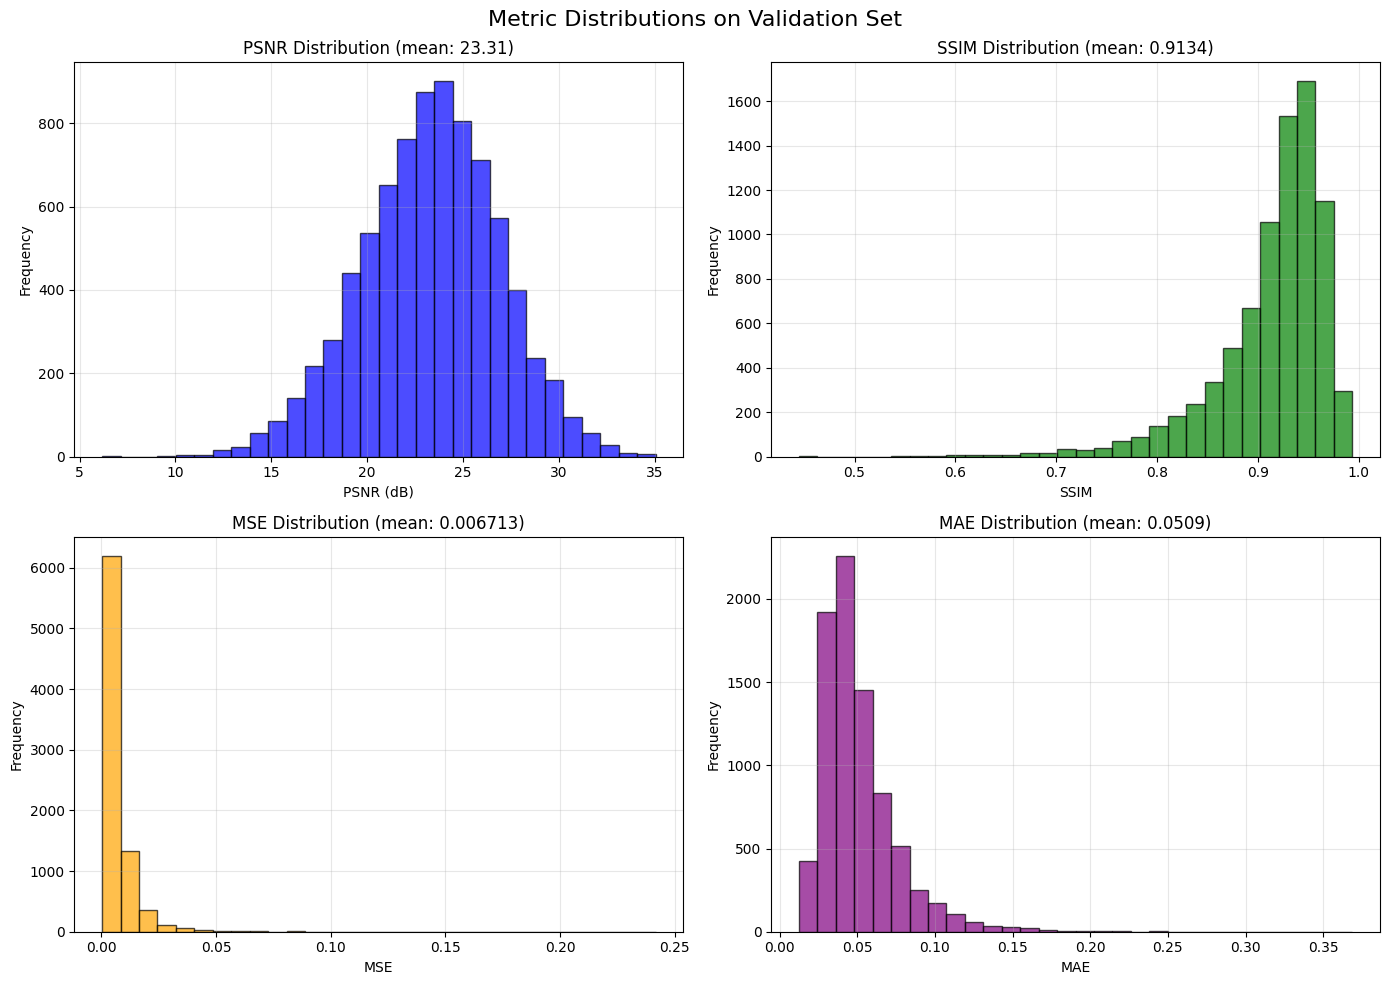


Metrics evaluation complete!


In [43]:
run_evaluation()